<a href="https://colab.research.google.com/github/Rudransh840/ML--Lab/blob/main/ML_Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Install and Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
#Load Dataset
data = load_breast_cancer()

x = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Shape:", x.shape)
print("Class Labels:", data.target_names)
x.head()

Dataset Shape: (569, 30)
Class Labels: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
#Train Test Split + Scaling
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


Experiment 1 : KNN Classifier

In [4]:
#Train Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)

In [5]:
#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:\n", cm)

print("Classification Report:\n", classification_report(y_test, y_pred_knn))

Accuracy: 0.9473684210526315
Confusion Matrix:
 [[40  3]
 [ 3 68]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



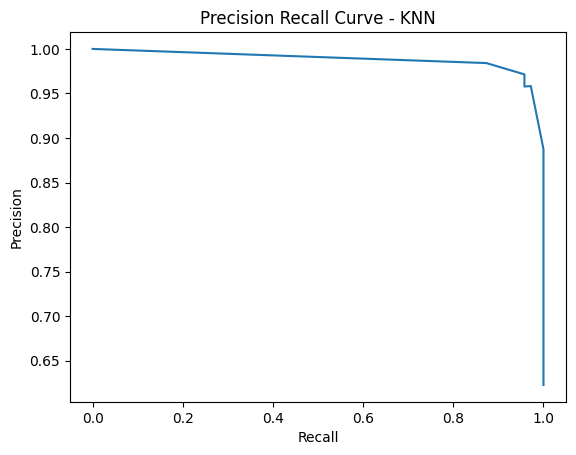

In [6]:
#Precision Recall Curve
y_scores_knn = knn.predict_proba(x_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_scores_knn)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve - KNN")
plt.show()

Experiment 2 : SVM

In [7]:
#Train Model
svm_model = SVC(probability=True)

svm_model.fit(x_train, y_train)

SVC(probability=True)

In [8]:
#Predict Test Data
y_pred_svm = svm_model.predict(x_test)

In [9]:
#Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

Accuracy: 0.9824561403508771


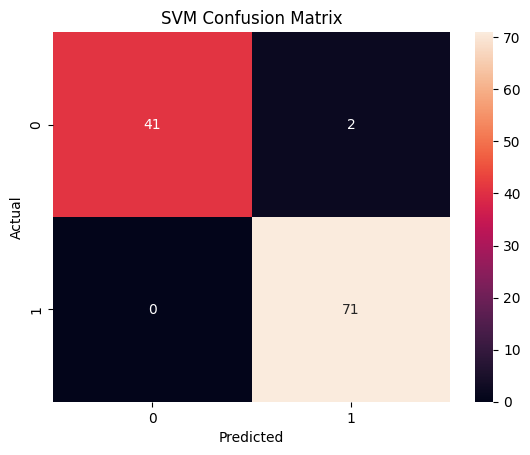

In [10]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
#Classification Report
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



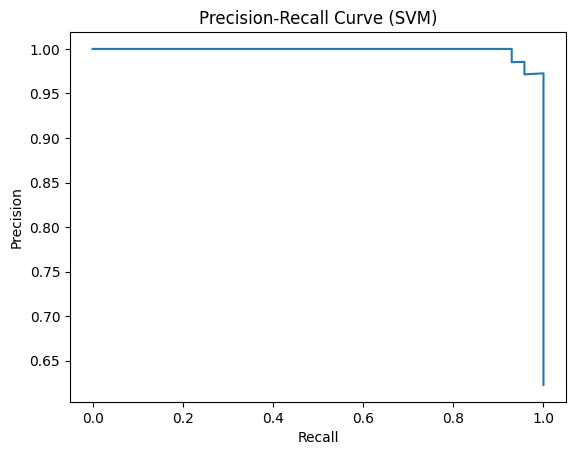

In [12]:
#Precision-Recall Curve
y_scores = svm_model.predict_proba(x_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (SVM)")
plt.show()

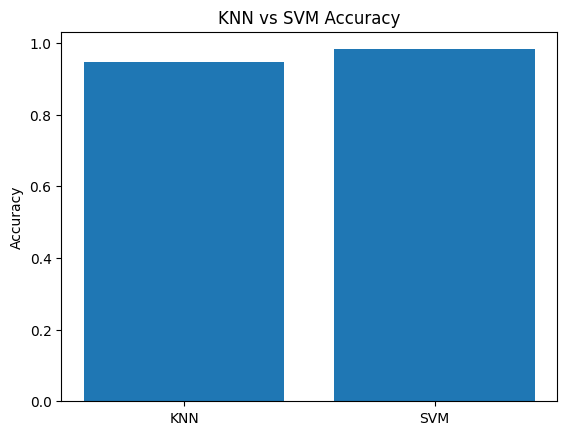

In [13]:
#Accuracy Comparison Code
knn_acc = accuracy_score(y_test, y_pred_knn)
svm_acc = accuracy_score(y_test, y_pred_svm)

models = ['KNN', 'SVM']
scores = [knn_acc, svm_acc]

plt.bar(models, scores)
plt.ylabel("Accuracy")
plt.title("KNN vs SVM Accuracy")
plt.show()

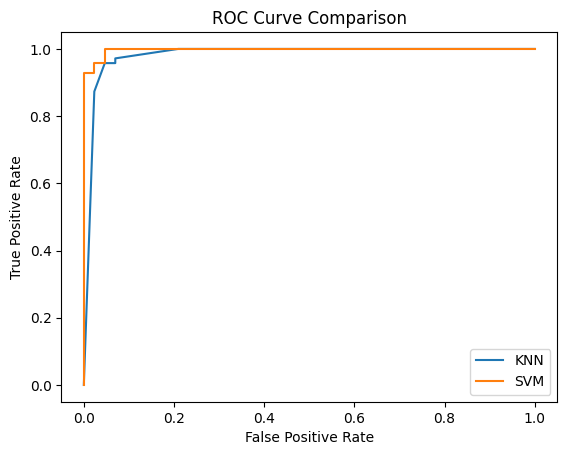

In [14]:
#ROC Curve Comparison
knn_prob = knn.predict_proba(x_test)[:,1]
svm_prob = svm_model.predict_proba(x_test)[:,1]

fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)

plt.plot(fpr_knn, tpr_knn, label="KNN")
plt.plot(fpr_svm, tpr_svm, label="SVM")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

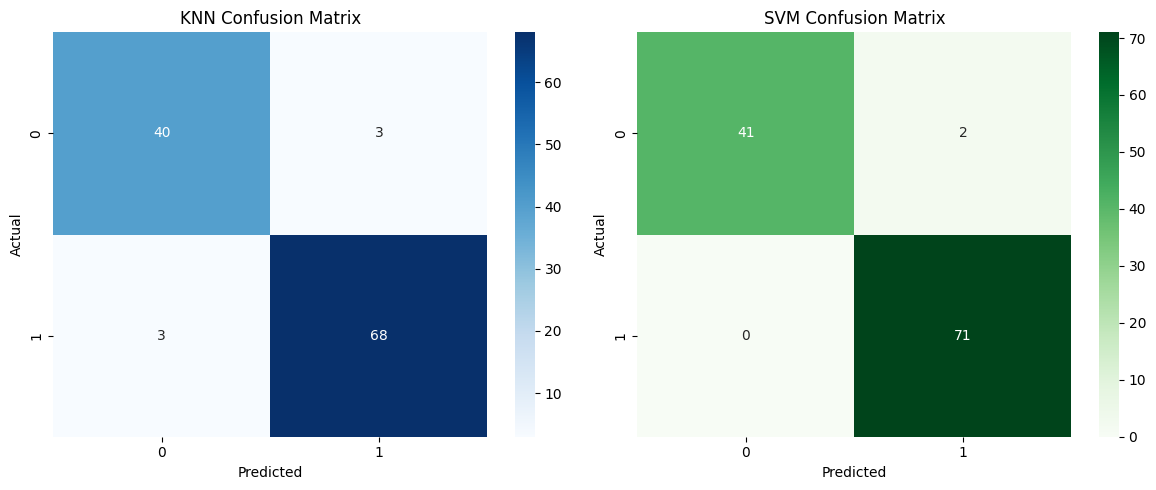

In [15]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("KNN Confusion Matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title("SVM Confusion Matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()